# Cavity

We study the stability condition of an optical cavity (bow-tie), its bandwidth, and so on.

In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.cm as cm
from matplotlib.tri import Triangulation, TriAnalyzer
from matplotlib.patches import Rectangle

In [3]:
from utils.plot_style import set_plot_style
from utils.plot_helper import cmap_map
set_plot_style()

In [4]:
from cavity.abcd import *
import cavity.cavity_formulas as cf

## Bandwidth

We identify the tuple $(T, L)$, output coupler and cavity length, enabling a given bandwidth.

### Color for plot

In [5]:
colors = ["orange", "yellow", "white", "lightblue", "darkblue"]
map = LinearSegmentedColormap.from_list("blue_purple_flag", colors)

# Diverging: purple -> white -> green
diverging_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    [
        (118/255, 42/255, 131/255),   # purple
        (247/255, 247/255, 247/255),  # white
        (27/255,  120/255, 55/255),   # green
    ]
)

# Sequential: cream -> orange -> dark brown
sequential_cmap = LinearSegmentedColormap.from_list(
    "custom_sequential",
    [
        (255/255, 225/255, 229/255),  # cream
        (251/255, 154/255, 41/255),   # orange
        (102/255, 37/255,  6/255),    # dark brown
    ]
)

In [6]:
map = diverging_cmap

### Parameters

In [7]:
N = 1000

In [8]:
# Cavity length
min_L, max_L = 0.4, 1.6
cavity_lengths = np.linspace(start=min_L, stop=max_L, num=N)  # 500mm to 1200mm

In [9]:
# Transmission coefficient
transmission_coefficients = np.linspace(start=0.03, stop=0.15, num=N)  # 5% to 15%
exact_T = np.array([5, 7, 10, 12]) * 1e-2
# Combine and sort to ensure the exact values are included
transmission_coefficients = np.unique(np.concatenate([transmission_coefficients, exact_T]))
transmission_coefficients.sort()

# Meshgrid
L, T = np.meshgrid(cavity_lengths, transmission_coefficients)

In [10]:
# Define the target bandwidth range
target_bandwidth = 6.0  # 6 MHz
tolerance = 0.1  # ±10%

bandwidth_min = target_bandwidth * (1 - tolerance)
bandwidth_max = target_bandwidth * (1 + tolerance)

In [11]:
# Loss inside cavity
loss = 0.02

### Compute Bandwidth

In [12]:
# Bow-tie
bandwidth_meshgrid = cf.bandwidth(T=T, Loss=loss, L=L) * 1e-6  # MHz

In [13]:
# Mask the region outside the desired range
mask = (bandwidth_meshgrid < bandwidth_min) | (bandwidth_meshgrid > bandwidth_max)
masked_bandwidth = np.ma.masked_array(bandwidth_meshgrid, mask)

### Valid Cavity ranges

From the bandwidth computation, for each output coupler we have (`exact_values` defined above), we save the corresponding length range.
We use the `masked_banwidth` variable.

In [14]:
target_bw = 6.0  # MHz

In [15]:
valid_lengths = []
for T_value in exact_T:

    bw_line = cf.bandwidth(T=T_value, L=cavity_lengths, Loss=loss
    ) * 1e-6

    valid = (bw_line >= bandwidth_min) & (bw_line <= bandwidth_max)
    lengths = cavity_lengths[valid]
    valid_lengths.append(lengths)

In [16]:
print(valid_lengths)

[array([0.51771772, 0.51891892, 0.52012012, 0.52132132, 0.52252252,
       0.52372372, 0.52492492, 0.52612613, 0.52732733, 0.52852853,
       0.52972973, 0.53093093, 0.53213213, 0.53333333, 0.53453453,
       0.53573574, 0.53693694, 0.53813814, 0.53933934, 0.54054054,
       0.54174174, 0.54294294, 0.54414414, 0.54534535, 0.54654655,
       0.54774775, 0.54894895, 0.55015015, 0.55135135, 0.55255255,
       0.55375375, 0.55495495, 0.55615616, 0.55735736, 0.55855856,
       0.55975976, 0.56096096, 0.56216216, 0.56336336, 0.56456456,
       0.56576577, 0.56696697, 0.56816817, 0.56936937, 0.57057057,
       0.57177177, 0.57297297, 0.57417417, 0.57537538, 0.57657658,
       0.57777778, 0.57897898, 0.58018018, 0.58138138, 0.58258258,
       0.58378378, 0.58498498, 0.58618619, 0.58738739, 0.58858859,
       0.58978979, 0.59099099, 0.59219219, 0.59339339, 0.59459459,
       0.5957958 , 0.596997  , 0.5981982 , 0.5993994 , 0.6006006 ,
       0.6018018 , 0.603003  , 0.6042042 , 0.60540541, 0.6066

### Plot

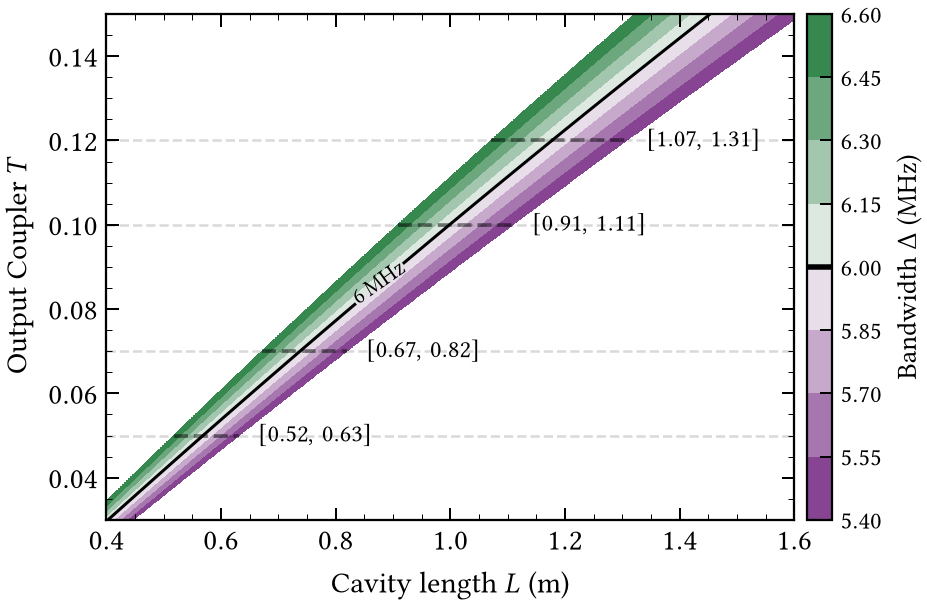

In [17]:
fig, ax = plt.subplots()

# Heatmap
contour = ax.contourf(
    L,
    T,
    masked_bandwidth,
    levels=10,
    cmap=map,
)

# Exact 6 MHz contour
iso = ax.contour(
    L,
    T,
    masked_bandwidth,
    levels=[target_bw],
    colors="black",
    linewidths=1.2,
    linestyles="-",
)

# Get the contour line vertices
# MATPLOTLIB VERSION >= 3.10
paths = iso.get_paths()

if len(paths) > 0:
    vertices = paths[0].vertices
    mid_x = np.mean(vertices[:, 0])
    mid_y = np.mean(vertices[:, 1])

    ax.clabel(
        iso,
        fmt={target_bw: r"$6\,\mathrm{MHz}$"},
        fontsize=9,
        colors="black",
        manual=[(0.95 * mid_x, 0.95 * mid_y)],
    )

# MATPLOTLIB VERSION < 3.10
# path = iso.collections[0].get_paths()[0]
# vertices = path.vertices
# mid_x = np.mean(vertices[:, 0])
# mid_y = np.mean(vertices[:, 1])
#
# # Optional inline label on the contour itself
# MH_label = ax.clabel(
#     iso,
#     fmt={target_bw: r"$6\,\mathrm{MHz}$"},
#     fontsize=9,
#     colors="black",
#     manual=[(0.95*mid_x, 0.95*mid_y)]
# )

# Colorbar
cbar = plt.colorbar(contour, ax=ax, pad=0.015)

cbar.set_label(
    r"Bandwidth $\Delta$ (MHz)",
    fontsize=11,
)

cbar.ax.tick_params(labelsize=10)

# Add horizontal marker on colorbar at 6 MHz
cbar.ax.axhline(
    target_bw,
    color="black",
    linewidth=2.2,
)

for T_value, valid_length in zip(exact_T, valid_lengths):
    # Horizontal lines for given coupler values
    ax.axhline(
        T_value,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.15,
    )

    ax.plot(
        valid_length,
        [T_value] * len(valid_length),
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.45,
    )

    range_min, range_max = valid_length[0], valid_length[-1]
    # Threshold: if the valid range ends close to the right edge of the plot
    margin = 0.1 * (max_L - cavity_lengths[0])  # % of total range

    if (max_L - range_max) < margin:
        # Too close to right edge → place label on the left
        x_text = range_min
        ha = "right"
        x_offset = -8
    else:
        # Enough room → place label on the right
        x_text = range_max
        ha = "left"
        x_offset = 8

    ax.annotate(
        rf"$[{range_min:.2f},\, {range_max:.2f}]$",
        xy=(x_text, T_value),
        xytext=(x_offset, 0),
        textcoords="offset points",
        ha=ha,
        va="center",
        fontsize=10,
        color="black",
    )

ax.set_xlabel(r"Cavity length $L$ (m)")
ax.set_ylabel(r"Output Coupler $T$")

plt.show()

## Propagation of Gaussian beam

We use the ABCD formalism to find the stable configurations of an optical cavity. When finding cavity configurations, we use the `valid_lengths` from the **Bandwidth** section, which correspond to the valid length for each available coupler to remain within a 10\% range of the targetted bandwidth.

### Sweep

The idea is for fixed length, RoC of the mirrors, and crystal lengths, to find the correct curved mirrors separation to have a stable cavity

#### Parameters

In [18]:
wavelength = 780e-9  # 780 nm

In [19]:
l_crystal = 20e-3 # 20 mm
index = 1.84

In [20]:
roc1 = 100e-3  # 100 mm
roc2 = 100e-3  # 100 mm

f1 = roc1 / 2
f2 = roc2 / 2

In [21]:
# Select the length range
i = 1 # ensure you use the proper index w.r.t the valid_lengths list length
start, stop = valid_lengths[i][0] * 1e3, valid_lengths[i][-1] * 1e3

print("start: ", start, "stop: ", stop)

# Fixed resolution
dL = 0.2  # mm
npts = int(np.round((stop - start) / dL)) + 1

start:  671.4714714714715 stop:  819.2192192192193


In [22]:
# Define the range of length
L_bowtie = np.linspace(start=start, stop=stop, num=npts) * 1e-3 # m
print(L_bowtie.shape)
d_curved_array = np.linspace(start=20, stop=260, num=2000) * 1e-3 # distance between curved mirror (mm)

(740,)


#### Bow-tie cavity sweep — computation logic

##### Geometry

The round-trip path is parameterised by two lengths derived from the two free
parameters $(L,\, d_\text{curved})$:

$$
l_1 = \frac{L - d_\text{curved}}{2}, \qquad
l_2 = \frac{d_\text{curved} - l_\text{crystal}}{2}
$$

- $l_1$ — arm length between a flat mirror and a curved mirror (depends on **both** $L$ and $d_\text{curved}$).
- $l_2$ — distance between a curved mirror and the crystal face (depends on $d_\text{curved}$ **only**).

##### Round-trip matrices

Two starting points are used to access the two intra-cavity waists.

**$M_2$ — starting at the flat-mirror waist**

$$
M_2 = \underbrace{M_\text{free}(l_1)}_{\text{varies with }L}
\underbrace{M_{f_2}\, M_\text{free}(l_2)\, M_\text{free}(l_c/n)\, M_\text{free}(l_2)\, M_{f_1}}_{M_{\text{inner},2}\ (\text{fixed for a given }d_\text{curved})}
\underbrace{M_\text{free}(l_1)}_{\text{varies with }L}
$$

**$M_1$ — starting at the curved-mirror waist**

$$
M_1 =
\underbrace{M_\text{free}(l_c/2n)\, M_\text{free}(l_2)\, M_{f_1}}_{M_{\text{left},1}}
\underbrace{M_\text{free}(2l_1)}_{\text{varies with }L}
\underbrace{M_{f_2}\, M_\text{free}(l_2)\, M_\text{free}(l_c/2n)}_{M_{\text{right},1}}
$$

##### Two-pass strategy

Because $l_2$ (and the blocks built from it) does **not** depend on $L$, the
inner matrix products are factored out and computed once per $d_\text{curved}$
value.

```
Pass 1 — loop over d_curved  (precomputation)
    compute l2
    assemble M_inner2, M_left1, M_right1   ← stored, never recomputed

Pass 2 — loop over L  ×  d_curved  (main sweep)
    compute l1 from (L, d_curved)
    assemble M2 = M_free(l1) @ M_inner2 @ M_free(l1)     ← 2 products
    assemble M1 = M_left1 @ M_free(2*l1) @ M_right1      ← 2 products
    solve for q1, q2  →  extract waist and position
```

The cost drops from **10** matrix products per $(L, d_\text{curved})$ pair to
**4**, with a one-time overhead of **5** products per $d_\text{curved}$ value.
For a sweep of $N_L$ cavity lengths and $N_d$ curved-mirror separations the
total number of $2\times 2$ matrix multiplications goes from

$$
10\, N_L N_d \quad\longrightarrow\quad 5\, N_d + 4\, N_L N_d
$$

which is roughly a **2× reduction** when $N_L$ is large.

In [23]:
# --- Precompute the d_curved-only matrix blocks (done once, reused across all L) ---
precomputed = []
for d_curved in d_curved_array:
    l2 = (d_curved - l_crystal) / 2

    # Middle block of M2: everything except the two outer M_free(l1)
    M_inner2 = (
        M_focal(f2)
        @ M_free(l2)
        @ M_free(l_crystal / index)
        @ M_free(l2)
        @ M_focal(f1)
    )

    # Left and right blocks of M1: everything except the central M_free(2*l1)
    M_left1  = M_free((l_crystal / 2) / index) @ M_free(l2) @ M_focal(f1)
    M_right1 = M_focal(f2) @ M_free(l2) @ M_free((l_crystal / 2) / index)

    precomputed.append((d_curved, M_inner2, M_left1, M_right1))

# --- Main sweep (l1 is the only quantity that changes with L) ---
waist1_values, z1_waist_values = [], []
waist2_values, z2_waist_values = [], []
L_stable, d_curved_stable = [], []

for L in L_bowtie:
    d_list = []
    w1_list, z1_list = [], []
    w2_list, z2_list = [], []

    for d_curved, M_inner2, M_left1, M_right1 in precomputed:
        l1 = (L - d_curved) / 2

        M2 = M_free(l1) @ M_inner2 @ M_free(l1)
        M1 = M_left1 @ M_free(2 * l1) @ M_right1

        q2 = eigen_q(M2)
        q1 = eigen_q(M1)

        if q1 is None or q2 is None:
            continue

        w1, z1 = waist_and_position(q1, wavelength)
        w2, z2 = waist_and_position(q2, wavelength)

        d_list.append(d_curved)
        w1_list.append(w1);  z1_list.append(z1)
        w2_list.append(w2);  z2_list.append(z2)

    if d_list:
        L_stable.append(L)
        d_curved_stable.append(np.array(d_list))

        waist1_values.append(np.array(w1_list))
        z1_waist_values.append(np.array(z1_list))

        waist2_values.append(np.array(w2_list))
        z2_waist_values.append(np.array(z2_list))

In [24]:
# How many values of L?
print("Number of stable cavity lengths: ", len(L_stable))

Number of stable cavity lengths:  740


### Plot

#### Fixed length waist plot

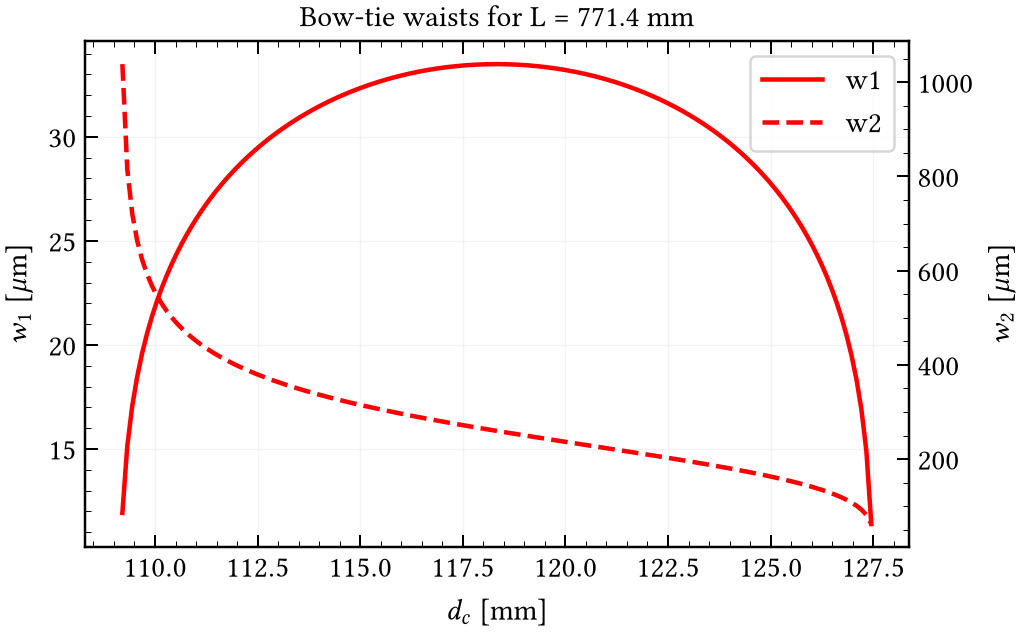

In [25]:
fig, ax1 = plt.subplots()

# Choose random index
i = np.random.randint(0, len(L_stable))

# Left axis: w1
ax1.plot(
    d_curved_stable[i] * 1e3,   # mm
    waist1_values[i] * 1e6,     # µm
    label="w1",
    color="red780",
)

ax1.set_xlabel(r"$d_c$ [mm]")
ax1.set_ylabel(r"$w_1$ [$\mu$m]")
ax1.grid()

# Right axis: w2
ax2 = ax1.twinx()

ax2.plot(
    d_curved_stable[i] * 1e3,   # mm
    waist2_values[i] * 1e6,     # µm
    label="w2",
    linestyle="--",
    color="red780"
)

ax2.set_ylabel(r"$w_2$ [$\mu$m]")

# Common title
plt.title(f"Bow-tie waists for L = {L_stable[i]*1e3:.1f} mm")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

#### Stability diagram plot

In [28]:
# Flatten list-of-arrays
L_plot = []
d_plot = []
w1_plot = []
w2_plot = []

for i, L in enumerate(L_stable):
    L_plot.extend([L] * len(d_curved_stable[i]))
    d_plot.extend(d_curved_stable[i])
    w1_plot.extend(waist1_values[i])
    w2_plot.extend(waist2_values[i])

L_plot = np.array(L_plot)
d_plot = np.array(d_plot)
w1_plot = np.array(w1_plot)
w2_plot = np.array(w2_plot)

In [30]:
z1 = w1_plot * 1e6
z2 = w2_plot * 1e6

In [40]:
x = L_plot * 1e3
y = d_plot * 1e3
z = z1

threshold = 0.0  # µm
mask = z > threshold

x_plot = x[mask]
y_plot = y[mask]
z_plot = z[mask]

tri = Triangulation(x_plot, y_plot)

Define proper cmap

In [72]:
n_colors = 20  # number of discrete levels

custom_red = LinearSegmentedColormap.from_list(
    "optical_red",
    [
        (0.00, "#fff3f2"),
        (0.20, "#FFD3CC"),
        (0.40, "#FFA59B"),
        (0.60, "#FF968B"),
        (0.80, "#FF746C"),
        (1.00, "#FF4A3B"),
    ],
    N=256
)

custom_red_light = cmap_map(lambda x: x/2 + 0.4, custom_red)

vmin_rd = z.max()
vmax_rd = z.min()

cmap = ListedColormap(custom_red_light(np.linspace(0, 1, n_colors)))

In [69]:
# --- choose the visual cutoff (add near your other parameters) ---
visual_cutoff = 0  # µm

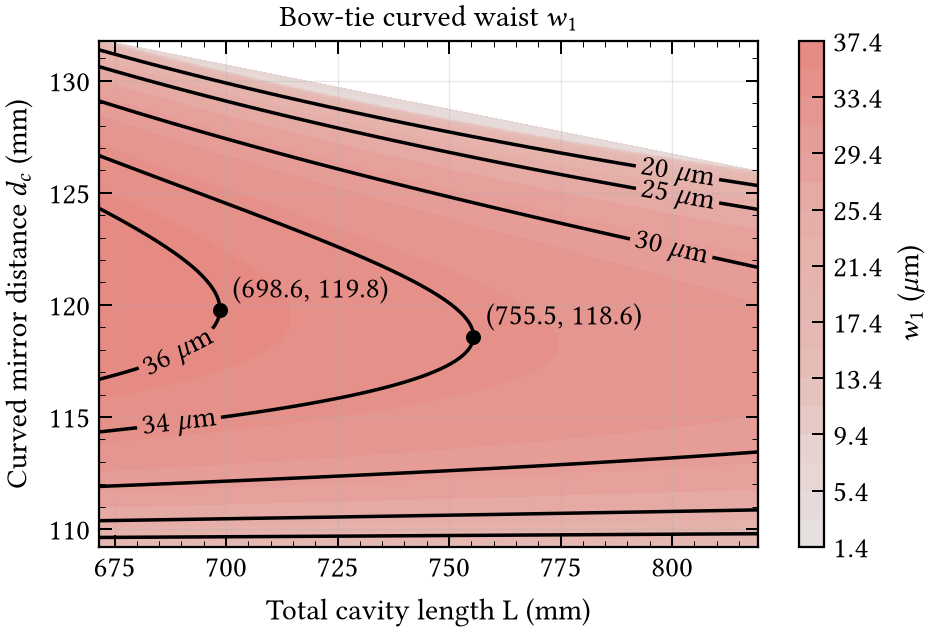

In [77]:
fig, ax = plt.subplots()

# Discretized filled contour
inc = 2.0
levels_fill = np.arange(z.min(), z.max() + inc, inc)

cf = ax.tricontourf(
    tri,
    z_plot,
    levels=levels_fill,
    cmap=cmap
)

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$w_1$ ($\mu$m)")

# Main contour lines
levels = [20, 25, 30, 34, 36]

CS = ax.tricontour(
    tri,
    z_plot,
    levels=levels,
    colors="black",
    linewidths=1.4
)

ax.set_xlabel("Total cavity length L (mm)")
ax.set_ylabel(r"Curved mirror distance $d_c$ (mm)")
ax.set_title(r"Bow-tie curved waist $w_1$")
ax.grid(alpha=0.3)

# Robust clabel placement
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

xmargin = 0.12 * (xmax - xmin)
ymargin = 0.12 * (ymax - ymin)

label_positions = []

for segs in CS.allsegs:

    if len(segs) == 0:
        continue

    seg = max(segs, key=len)

    mask = (
        (seg[:, 0] > xmin + xmargin) &
        (seg[:, 0] < xmax - xmargin) &
        (seg[:, 1] > ymin + ymargin) &
        (seg[:, 1] < ymax - ymargin)
    )

    if np.sum(mask) < 5:
        continue

    seg_safe = seg[mask]

    dx = np.diff(seg_safe[:, 0])
    dy = np.diff(seg_safe[:, 1])

    # Normalize by axis extent so units don't skew the comparison
    ax_w = xmax - xmin
    ax_h = ymax - ymin
    slopes = np.abs((dy / ax_h) / (dx / ax_w + 1e-9))  # aspect-corrected |dy/dx|

    idx = np.argmin(slopes)
    pos = (
        0.5 * (seg_safe[idx, 0] + seg_safe[idx + 1, 0]),
        0.5 * (seg_safe[idx, 1] + seg_safe[idx + 1, 1]),
    )

    label_positions.append(tuple(seg_safe[idx]))

stability_color = "k"
edge_tol = 0.01 * (xmax - xmin)

for level, segs in zip(levels, CS.allsegs):
    if not segs:
        continue

    seg = max(segs, key=lambda s: s[:, 0].max())
    idx = np.argmax(seg[:, 0])
    x_tip, y_tip = seg[idx]

    if x_tip > xmax - edge_tol:
        continue  # tip is just where the contour exits the plot, skip it

    ax.plot(x_tip, y_tip, "o", color=stability_color)
    ax.annotate(
        f"({x_tip:.1f}, {y_tip:.1f})",
        xy=(x_tip, y_tip),
        xytext=(5, 5),
        textcoords="offset points",
        color=stability_color
    )

texts = ax.clabel(
    CS,
    inline=True,
    fmt=r"%d $\mu$m",
    manual=label_positions
)

for txt in texts:
    txt.set_color("black")

# plt.tight_layout()
plt.show()

In [78]:
fig.savefig("./figure/" + "coupler_7_stable_cavity.svg", dpi=300)